# Analiza Głównych Składowych (PCA)

**Cel:** Redukcja wymiarowości danych (usunięcie szumu i redundancji) przy jednoczesnym zachowaniu jak największej ilości informacji o spółkach.

### Krok 1: Wczytanie i ostateczne czyszczenie danych
Wczytujemy nasz przygotowany plik `aggregated_company_data.csv`. Ponieważ PCA operuje wyłącznie na liczbach i nie toleruje braków danych (NaN), stosujemy imputację: puste wartości wypełniamy zerem, co w przypadku naszych **ustandaryzowanych danych** oznacza po prostu przypisanie danej spółce rynkowej średniej. Usuwamy również z analizy kolumny kategoryczne/identyfikatory.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

LOCAL_FOLDER = Path.cwd().parent / "local_folder"
df_pca = pd.read_csv(LOCAL_FOLDER / 'aggregated_company_data.csv')

df_pca = df_pca.replace([np.inf, -np.inf], np.nan)
df_pca = df_pca.fillna(0)


### Krok 2: Eliminacja kolumn, które dublują informacje o waiancji
Np. Revenue_WMA, Revenue_std, Revenue_cv, Revenue_slope są wyliczane z tej samej agregogowanej kolumny "Revenue"

Za pomocą PCAnalysis wybieramy, która z tych czterech metryk opisuje najwięcej wariancji w danej Składowej Głównej X (PCx)

In [2]:
names_tuple = ('_WMA', '_std', '_cv', '_slope')
doubled_columns = [col for col in df_pca.columns if col.endswith(names_tuple)]

double_col_df = df_pca[doubled_columns]

pca_1 = PCA()
pca_1.fit(double_col_df)

explained_variance = pca_1.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Składowa': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Wariancja (%)': explained_variance,
    'Skumulowana wariancja (%)': cumulative_variance
})

print("Tabela Wariancji Wyjaśnionej dla kolumn WMA, STD, CV, SLOPE:")
display(pca_summary.round(2))

Tabela Wariancji Wyjaśnionej dla kolumn WMA, STD, CV, SLOPE:


,Składowa,Wariancja (%),Skumulowana wariancja (%)
0,PC1,25.73,25.73
1,PC2,12.54,38.26
2,PC3,8.13,46.40
3,PC4,7.41,53.81
4,PC5,6.73,60.54
5,PC6,5.80,66.34
6,PC7,5.17,71.51
7,PC8,4.96,76.48
8,PC9,4.35,80.83
9,PC10,4.13,84.96


### Krok 3: Heatmapa dla metryk doublujących się

Tabela **Ładunków (Loading_scores)** pokazuje wpływ (od -1 do 1) oryginalnych metryk na nowe Składowe. Jeśli jakaś zmienna ma dużą wartość bezwzględną (np. 0.8 lub -0.7) w kolumnie PC1, oznacza to, że PC1 w dużej mierze reprezentuje właśnie tę oryginalną metrykę. Generujemy heatmapę dla graficznej wizualizacji.

Na podstawie tej heatmapy decyzdujemy, która z pośród czterech statystyk dla danej matryki podstawowej niesie najwięcej informacji o wariancji 

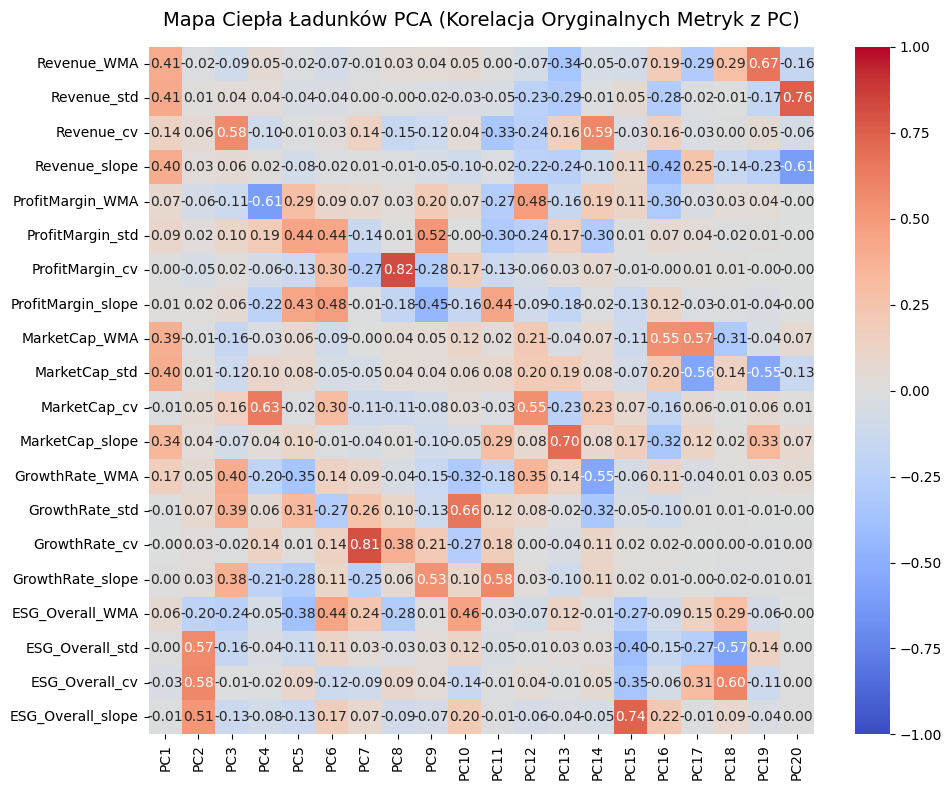

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
Revenue_WMA,0.409003,-0.016815,-0.094553,0.049851,-0.017946,-0.067007,-0.013757,0.034014,0.043318,0.047461,0.002649,-0.073191,-0.344663,-0.053675,-0.073518,0.190265,-0.290538,0.287590,0.671068,-0.156927
Revenue_std,0.414103,0.013359,0.038200,0.037236,-0.043777,-0.038406,0.003347,-0.004611,-0.023537,-0.032864,-0.045372,-0.234101,-0.289419,-0.013302,0.051753,-0.276590,-0.020679,-0.005533,-0.171196,0.755439
Revenue_cv,0.139560,0.059164,0.576526,-0.100569,-0.010371,0.029825,0.136918,-0.154719,-0.116069,0.036037,-0.328670,-0.240828,0.157620,0.592221,-0.034732,0.163841,-0.030957,0.002606,0.049058,-0.055327
Revenue_slope,0.404198,0.030757,0.059690,0.020511,-0.083984,-0.018869,0.006760,-0.009549,-0.052030,-0.096318,-0.016999,-0.219972,-0.241840,-0.097822,0.106400,-0.420554,0.253520,-0.141876,-0.228865,-0.608658
ProfitMargin_WMA,0.071167,-0.062704,-0.109909,-0.605328,0.291598,0.086822,0.072940,0.025249,0.197415,0.068945,-0.268745,0.481636,-0.155097,0.190245,0.114253,-0.298180,-0.033635,0.032570,0.040422,-0.003694
ProfitMargin_std,0.086622,0.024206,0.101840,0.193896,0.444264,0.436741,-0.136885,0.007634,0.515541,-0.002392,-0.304028,-0.235650,0.170754,-0.295656,0.006195,0.067608,0.041408,-0.015386,0.012294,-0.000996
ProfitMargin_cv,0.004457,-0.053388,0.017787,-0.064649,-0.132509,0.303157,-0.268468,0.822034,-0.279998,0.174508,-0.131696,-0.062343,0.025717,0.065039,-0.010840,-0.003432,0.010437,0.011620,-0.000686,-0.002934
ProfitMargin_slope,0.012362,0.016460,0.058271,-0.220748,0.432496,0.477777,-0.009845,-0.177345,-0.452908,-0.158883,0.442110,-0.092385,-0.183866,-0.020297,-0.125316,0.118147,-0.028672,-0.011574,-0.037039,-0.002138
MarketCap_WMA,0.388572,-0.009548,-0.159400,-0.030254,0.056148,-0.089660,-0.003337,0.043900,0.045157,0.115346,0.022499,0.213320,-0.039924,0.071752,-0.108495,0.547630,0.569627,-0.314749,-0.039469,0.067828
MarketCap_std,0.404816,0.010035,-0.116670,0.100779,0.075791,-0.048835,-0.052788,0.040989,0.036607,0.060625,0.081084,0.198650,0.194915,0.082564,-0.068621,0.199728,-0.559797,0.143140,-0.554302,-0.134483


In [3]:
num_components_to_analyze = len(explained_variance)

loadings = pd.DataFrame(
    pca_1.components_.T[:, :num_components_to_analyze], 
    columns=[f'PC{i+1}' for i in range(num_components_to_analyze)],
    index=double_col_df.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Mapa Ciepła Ładunków PCA (Korelacja Oryginalnych Metryk z PC)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

display(loadings)

### Krok 4: Ranking metryk dla Revenue, ProfitMargin, MarketCap, GrowthRate, ESG
Na podstawie wyników z poprzedniego kroku wstawiamy wyniki do wzoru:

#### PCA-based Feature Importance (Ważone Ładunki Absolutne)

Aby wyłonić najważniejsze metryki z modelu PCA, obliczamy ich globalną istotność, ważąc bezwzględne wartości ładunków (loading scores) procentowym udziałem danego komponentu w wyjaśnianiu wariancji. Metoda ta pozwala wyłonić cechy, które niosą najwięcej unikalnych informacji o całym zbiorze danych.

$$I_j = \sum_{i=1}^{k} \lambda_i |l_{i,j}|$$

**Wyjaśnienie zmiennych:**
*   $I_j$ – Ostateczna istotność (waga) oryginalnej cechy (metryki) $j$. Im wyższa wartość, tym metryka silniej różnicuje analizowany rynek.
*   $k$ – Liczba uwzględnianych głównych składowych (PC), najczęściej dobierana tak, aby pokryć optymalny próg skumulowanej wariancji (np. 75%).
*   $\lambda_i$ – Procent całkowitej wariancji wyjaśnianej przez składową $i$. Stanowi wagę ważności danego komponentu (w bibliotece `scikit-learn` jest to wartość z `pca.explained_variance_ratio_`).
*   $l_{i,j}$ – Ładunek (loading score) cechy $j$ w składowej $i$. Określa siłę korelacji metryki z danym komponentem, stąd zastosowanie wartości bezwzględnej (w `scikit-learn` pobierany z macierzy `pca.components_`).

In [4]:
weighted_importance = np.dot(pca_1.explained_variance_ratio_, np.abs(pca_1.components_))

feature_importance_df = pd.DataFrame({
    'Metryka': double_col_df.columns,
    'Istotnosc_PCA': weighted_importance
}).sort_values(by='Istotnosc_PCA', ascending=False)

display(feature_importance_df)

,Metryka,Istotnosc_PCA
12,GrowthRate_WMA,0.188972
16,ESG_Overall_WMA,0.176193
5,ProfitMargin_std,0.162368
9,MarketCap_std,0.162054
2,Revenue_cv,0.159470
11,MarketCap_slope,0.159065
4,ProfitMargin_WMA,0.158202
8,MarketCap_WMA,0.156694
3,Revenue_slope,0.153075
13,GrowthRate_std,0.152551


### Krok 5: Wybór metryk na podstawie rankingu

In [5]:
regular_metrics_columns = []
prefix_controller = []

for col in feature_importance_df['Metryka']:
    prefix = str.split(col, '_')[0]

    if prefix not in prefix_controller:
        regular_metrics_columns.append(col)
        prefix_controller.append(prefix)

for col in regular_metrics_columns:
    print(col)

GrowthRate_WMA
ESG_Overall_WMA
ProfitMargin_std
MarketCap_std
Revenue_cv


### Krok 6: Definiujemy sztywną listę konkretnych metryk
Na podstawie outputu w poprzednim korku

In [6]:
calculated_metrics_columns = [
    'PriceToSales', 
    'NetIncome', 
    'PriceToEarnings', 
    'EarningsYield',
    'Risk-AdjustedGrowth', 
    'Earnings-to-Growth', 
    'ESG_Signal-to-Noise'
]

final_columns = regular_metrics_columns + calculated_metrics_columns


# Z ORYGINALNEJ TABELI zostawiamy tylko te metryki 

X = df_pca[final_columns]

print(f"Dane gotowe do PCA. Liczba wierszy: {X.shape[0]}, Liczba analizowanych metryk: {X.shape[1]}")
display(X.head())

Dane gotowe do PCA. Liczba wierszy: 1000, Liczba analizowanych metryk: 12


,GrowthRate_WMA,ESG_Overall_WMA,ProfitMargin_std,MarketCap_std,Revenue_cv,PriceToSales,NetIncome,PriceToEarnings,EarningsYield,Risk-AdjustedGrowth,Earnings-to-Growth,ESG_Signal-to-Noise
0,0.1508,0.0865,-0.9564,-0.3192,-0.1766,-1.0324,-0.3468,0.0282,0.7872,-0.0009,-0.1307,0.1229
1,0.3774,0.5564,-0.5644,-0.1572,0.4816,-0.7591,-0.3738,-0.3299,-1.8923,-0.1424,0.0335,0.1850
2,0.2648,-1.5734,-0.0744,-0.3129,-0.3960,-0.5417,-0.3435,0.0344,0.1917,0.3280,-0.1351,-0.3735
3,0.2282,0.3771,-1.2014,0.0533,-0.1766,2.6327,0.4073,0.0550,-0.4037,-0.0610,-0.1136,0.9917
4,-0.4162,-0.6258,-0.3929,-0.2096,-1.0542,0.2286,-0.0232,0.0268,0.7872,-0.2202,-0.1162,-0.9941


### Krok 7: Uruchomienie modelu i analiza wariancji
Inicjujemy model PCA. Liczymy *Explained Variance*, która powie nam, ile wiedzy o spółkach niesie w sobie każda kolejna składowa PC.

In [7]:
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Składowa': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Wariancja (%)': explained_variance,
    'Skumulowana wariancja (%)': cumulative_variance
})

print("Tabela Wariancji Wyjaśnionej:")
display(pca_summary.round(2))

Tabela Wariancji Wyjaśnionej:


,Składowa,Wariancja (%),Skumulowana wariancja (%)
0,PC1,19.30,19.30
1,PC2,12.53,31.83
2,PC3,11.54,43.36
3,PC4,11.17,54.53
4,PC5,9.13,63.66
5,PC6,7.41,71.08
6,PC7,6.44,77.52
7,PC8,5.80,83.32
8,PC9,5.42,88.74
9,PC10,4.91,93.65


### Krok 8: Interpretacja Składników głównych
Skoro wiemy już, ile wymiarów potrzebujemy, musimy zrozumieć, co one z biznesowego punktu widzenia oznaczają. 

Bierzemy tyle Składników Głównych (Principal Components), aby ich **Skumulowana Wariancja** wynosiła między 75 a 80%. Są to standardy stosowane w literaturze, dzięki którym odszumiamy znacząco dane, jednocześnie unikając overfittingu.

#### Na podstawie wyników powyżej:
cumulative_variance > 75% oraz < 80% dla PC6

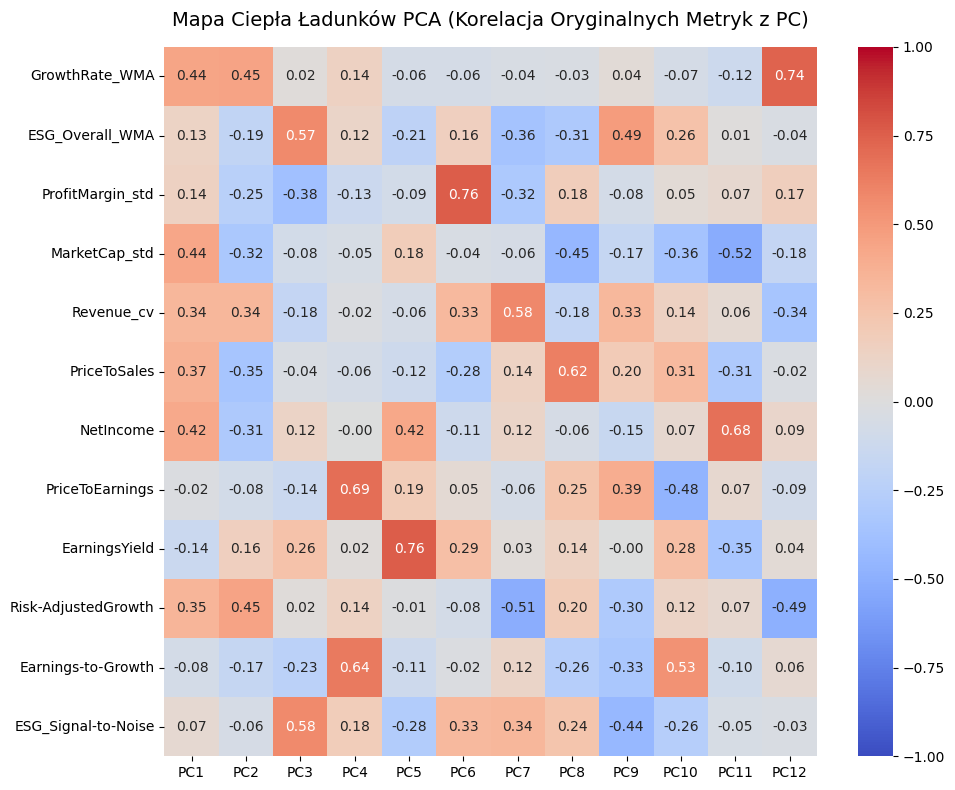

In [8]:
num_components_to_analyze = len(explained_variance)

loadings = pd.DataFrame(
    pca.components_.T[:, :num_components_to_analyze], 
    columns=[f'PC{i+1}' for i in range(num_components_to_analyze)],
    index=X.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Mapa Ciepła Ładunków PCA (Korelacja Oryginalnych Metryk z PC)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

#### Najważniejszy loading dla każdej Składowej Głównej

In [9]:
pc_columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']

loadings = pd.DataFrame(
    pca.components_.T[:, :len(pc_columns)],
    columns = pc_columns,
    index = X.columns
)

print("=== SKŁADOWA PC1 ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC2 ===")
print(loadings['PC2'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC3 ===")
print(loadings['PC3'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC4 ===")
print(loadings['PC4'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC5 ===")
print(loadings['PC5'].abs().sort_values(ascending=False).head(1))

print("\n=== SKŁADOWA PC6 ===")
print(loadings['PC6'].abs().sort_values(ascending=False).head(1))

=== SKŁADOWA PC1 ===
GrowthRate_WMA    0.440926
Name: PC1, dtype: float64

=== SKŁADOWA PC2 ===
Risk-AdjustedGrowth    0.449053
Name: PC2, dtype: float64

=== SKŁADOWA PC3 ===
ESG_Signal-to-Noise    0.575758
Name: PC3, dtype: float64

=== SKŁADOWA PC4 ===
PriceToEarnings    0.688464
Name: PC4, dtype: float64

=== SKŁADOWA PC5 ===
EarningsYield    0.764685
Name: PC5, dtype: float64

=== SKŁADOWA PC6 ===
ProfitMargin_std    0.758382
Name: PC6, dtype: float64


### Krok 9: Wybór 3 metryk najlepiej oddających wariancję zbioru danych dla PC1-PC6
Ponowne użycie wzoru **PCA-based Feature Importance**
$$I_j = \sum_{i=1}^{k} \lambda_i |l_{i,j}|$$

In [10]:
weighted_metrics_importance = np.dot(pca.explained_variance_ratio_, np.abs(pca.components_))

metrics_importance_df = pd.DataFrame({
    'Metryka': X.columns,
    'Istotnosc_PCA': weighted_metrics_importance
}).sort_values(by='Istotnosc_PCA', ascending=False)

display(metrics_importance_df)

,Metryka,Istotnosc_PCA
4,Revenue_cv,0.246211
1,ESG_Overall_WMA,0.241107
5,PriceToSales,0.240361
3,MarketCap_std,0.238175
11,ESG_Signal-to-Noise,0.232727
9,Risk-AdjustedGrowth,0.231491
6,NetIncome,0.229548
2,ProfitMargin_std,0.225645
10,Earnings-to-Growth,0.218053
0,GrowthRate_WMA,0.206919


### W fuzzy_rules_27.ipynb zostały uzyte: 
`EarningsYield`, `Risk-AdjustedGrowth`, `ESG_Signal-to-Noise`
### W fuzzy_rules.ipynb zostały użyte: 
`Earnings-to-Growth`, `ESG_Signal-to-Noise`, `ProfitMargin_WMA`, `PriceTosales`
### Analiza Składników Głównych wytypowała:
`Revenue_cv`, `NetIncome`, `ESG_Signal-to-Noise`

*Należy zauważyć, że te metryki `Revenue` i `NetIncome` są ze sobą powiązane. `NetIncome` wyliczamy poprzez przemnożenie `Revenue_mean` i `ProfitMargin_mean`. Jednakże zaproponowana metryka to `Revenue_cv`, czyli współczynnik zmienności przychodów firmy*

## Krok 10: Następstwa i hipotezy

Porównanie dwóch fuzzy systems 

1) Na podstawie analizy eksperckiej danych (arbitralny dobór metryk)
2) Na podstawie Principal Component Analysis (dobór metryk dokonywany przez algorytm PCA)

Podejście **(2)** jest uniwersalne dla danych nie tylko finansowych. Zaproponowana metoda analizy i przetwarzania danych może być stosowana do danych:
- medycznych
- finansowych
- ekologicznych
- wsm wszystkich xD